<a href="https://colab.research.google.com/github/farkhad-gazizov/educational/blob/main/%D0%94%D0%BE%D0%BC%D0%B0%D1%88%D0%BD%D0%B5%D0%B5_%D0%B7%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B5_%C2%AB%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_pandas%C2%BB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание «Библиотека pandas»


**Задание 1**

Датасет для домашнего задания находится в материалах занятия - файлы для домашнего задания «Библиотека Pandas».

Определите, какому фильму было выставлено больше всего оценок 5.0.

In [ ]:
import pandas as pd

In [ ]:
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [ ]:
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100836 entries, 0 to 100835
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100836 non-null  int64  
 1   movieId    100836 non-null  int64  
 2   rating     100836 non-null  float64
 3   timestamp  100836 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [ ]:
# в датафрейме находим ratings ID фильма с наибольшим количеством оценок 5.0
the_best_movie_id = ratings[ratings['rating'] == 5.0].groupby('movieId')['rating'].count().idxmax()

In [ ]:
# из датафрейма movies по найденному ID получаем название фильма
movies[movies['movieId'] == the_best_movie_id]['title'].values[0]

'Shawshank Redemption, The (1994)'

**Задание 2**

По данным файла power.csv посчитайте суммарное потребление стран Прибалтики (Латвия, Литва и Эстония) категорий 4, 12 и 21 за период с 2005 по 2010 год. Не учитывайте в расчётах отрицательные значения quantity.

In [ ]:
power = pd.read_csv('power.csv')
power.head()

,country,year,quantity,category
0,Austria,1996,5.0,1
1,Austria,1995,17.0,1
2,Belgium,2014,0.0,1
3,Belgium,2013,0.0,1
4,Belgium,2012,35.0,1


In [ ]:
power.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1189482 entries, 0 to 1189481
Data columns (total 4 columns):
 #   Column    Non-Null Count    Dtype  
---  ------    --------------    -----  
 0   country   1189482 non-null  object 
 1   year      1189482 non-null  int64  
 2   quantity  1189482 non-null  float64
 3   category  1189482 non-null  int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 36.3+ MB


In [ ]:
# находим, как называются нужные страны в датафрейме
power[power['country'].str.contains('lat|lit|est', case=False) ]['country'].unique()

array(['Lithuania', 'Latvia', 'Estonia', 'State of Palestine',
       'Timor-Leste'], dtype=object)

In [ ]:
# фильтруем нужные страны
filtered_countries = power[
    (power['country']=='Latvia') |
    (power['country']=='Lithuania') |
    (power['country']=='Estonia')
    ]
filtered_countries.head()

,country,year,quantity,category
373,Lithuania,2014,39.0,1
374,Lithuania,2013,192.0,1
375,Lithuania,2012,196.0,1
376,Lithuania,2011,171.0,1
377,Lithuania,2010,158.0,1


In [ ]:
# фильтруем нужные категории
filtered_countries = filtered_countries[
    (filtered_countries['category'] == 4) |
    (filtered_countries['category'] == 12) |
    (filtered_countries['category'] == 21)
    ]
filtered_countries.head()

,country,year,quantity,category
10617,Estonia,2008,1.0,4
10618,Estonia,2007,0.0,4
10619,Estonia,2006,0.0,4
10620,Estonia,2005,1.0,4
10621,Estonia,2004,1.0,4


In [ ]:
# фильтруем нужные годы
filtered_countries = filtered_countries[
    (filtered_countries['year'] >= 2005) &
    (filtered_countries['year'] <= 2010)
    ]
filtered_countries.head()

,country,year,quantity,category
10617,Estonia,2008,1.0,4
10618,Estonia,2007,0.0,4
10619,Estonia,2006,0.0,4
10620,Estonia,2005,1.0,4
11156,Lithuania,2008,1.0,4


In [ ]:
filtered_countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 411 entries, 10617 to 253986
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   country   411 non-null    object 
 1   year      411 non-null    int64  
 2   quantity  411 non-null    float64
 3   category  411 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 16.1+ KB


In [ ]:
# оставляем неотрицательные значения потребления
filtered_countries = filtered_countries[
    (filtered_countries['quantity'] >= 0.0)]
filtered_countries.head()

,country,year,quantity,category
10617,Estonia,2008,1.0,4
10618,Estonia,2007,0.0,4
10619,Estonia,2006,0.0,4
10620,Estonia,2005,1.0,4
11156,Lithuania,2008,1.0,4


In [ ]:
filtered_countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 408 entries, 10617 to 253986
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   country   408 non-null    object 
 1   year      408 non-null    int64  
 2   quantity  408 non-null    float64
 3   category  408 non-null    int64  
dtypes: float64(1), int64(2), object(1)
memory usage: 15.9+ KB


In [ ]:
filtered_countries['quantity'].sum()

np.float64(240580.0)

**Задание 3**

Выберите страницу любого сайта с табличными данными. Импортируйте таблицы в pandas DataFrame. Вы можете взять любые страницы.
Примеры страниц:

https://fortrader.org/quotes

https://pythonworld.ru/tipy-dannyx-v-python/stroki-funkcii-i-metody-strok.html

In [ ]:
page_url = 'https://pythonworld.ru/tipy-dannyx-v-python/stroki-funkcii-i-metody-strok.html'

df = pd.read_html(page_url)
df

[                                    Функция или метод  \
 0   S = 'str'; S = "str"; S = '''str'''; S = """st...   
 1                                  S = "s\np\ta\nbbb"   
 2                                  S = r"C:\temp\new"   
 3                                         S = b"byte"   
 4                                             S1 + S2   
 5                                              S1 * 3   
 6                                                S[i]   
 7                                         S[i:j:step]   
 8                                              len(S)   
 9                          S.find(str, [start],[end])   
 10                        S.rfind(str, [start],[end])   
 11                        S.index(str, [start],[end])   
 12                       S.rindex(str, [start],[end])   
 13              S.replace(шаблон, замена[, maxcount])   
 14                                    S.split(символ)   
 15                                        S.isdigit()   
 16           

In [ ]:
# проверяем количество таблиц в списке df, количество сходится с сайтом
print(len(df))

1


In [ ]:
# получаем pandas dataframe
df = df[0]
df.head()

,Функция или метод,Назначение
0,"S = 'str'; S = ""str""; S = '''str'''; S = """"""st...",Литералы строк
1,"S = ""s\np\ta\nbbb""",Экранированные последовательности
2,"S = r""C:\temp\new""",Неформатированные строки (подавляют экранирова...
3,"S = b""byte""",Строка байтов
4,S1 + S2,Конкатенация (сложение строк)


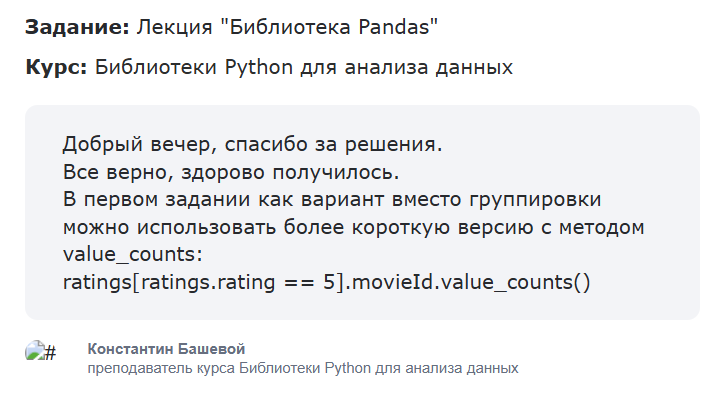

In [ ]:
import pandas as pd

In [ ]:
movies = pd.read_csv('movies.csv')
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
ratings = pd.read_csv('ratings.csv')
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [ ]:
the_best_movie_id = ratings[ratings.rating == 5.0].movieId.value_counts()
the_best_movie_id

,count
movieId,
318,153
296,123
356,116
2571,109
260,104
...,...
5139,1
4794,1
407,1
